In [3]:
#### Necessary libraries ####

import numpy as np  # Numpy is the fundamental package for scientific computing in Python.
import pandas as pd
from Functions import *
import pylab
from combine_data import read_data, read_precip_era5, read_tracked_precip
from paths import basedir, figure_path
from sklearn.cluster import KMeans

# The statement below enforces the plots to be put into this notebook, instead of in their own windows.
%matplotlib inline

# Data loading

In [4]:
########################################################
## INPUT soecifications ###
########################################################
case = "Pakistan"

########################################################
## import model runs                                  ##
########################################################
ds_sources = read_data(basedir, case)

########################################################
## WRF-WVT                                            ##
########################################################
# Just csv file because of nature of simulations #
csv_wrf_wvt = pd.read_csv(
    basedir + "/" + case + "/results WRF-WVT/" + case + "Case_Final.csv",
    sep=";",
    decimal=",",
    index_col=0,
)



Loading WRF-WVT data for Pakistan
Loading wam2layers data for Pakistan
Loading 2ldrm data for Pakistan
Loading utrack data for Pakistan
Loading btrims data for Pakistan
Loading tracmass data for Pakistan
Loading ughent data for Pakistan
Loading UIB data for Pakistan
Loading UniVie data for Pakistan
Loading CHc data for Pakistan
Loading xu data for Pakistan
Loading tatfancheng data for Pakistan
Loading uvigo data for Pakistan


In [48]:
#### model runs for plotting ####

# TODO: fix WAM2layers units (?)
list_reordered = [
    "WAM2layers",
    "2LDRM",
    #'UTrack Ens1',
    "UTrack Ens2",
    #'UTrack Ens3',
    #'UTrack Ens4',
    #'UTrack Ens5',
    "BTrIMS",
    "TRACMASS",
    #'FLEXPART-HAMSTER Ens1',
    #'FLEXPART-HAMSTER Ens2',
    #'FLEXPART-HAMSTER Ens3',
    #'FLEXPART-HAMSTER Ens4',
    "FLEXPART-SSW08 (HAMSTER) Ens5",
    "FLEXPART-SSW08 (WaterSip)",
    "FLEXPART-SSW08 (UniVie)",
    "LAGRANTO-SSW08",
    "FLEXPART-SSW08 (IBCAS)",
    "FLEXPART-SSW08 (HKUST) Ens2",
    "FLEXPART-SSW08 (LATTIN)",
    #'WRF-WVT',
    "FLEXPART-SJ04 (LATTIN)",
]

all_maps = {kk: ds_sources[kk] for kk in list_reordered}
all_maps = xr.Dataset(all_maps)

#Select area of interest without nans
all_maps = all_maps.sel(lat=slice(-30, 40), lon=slice(40, 85))

#Set nans to zero
all_maps = all_maps.fillna(0)

# Calculate clusters/EOFs

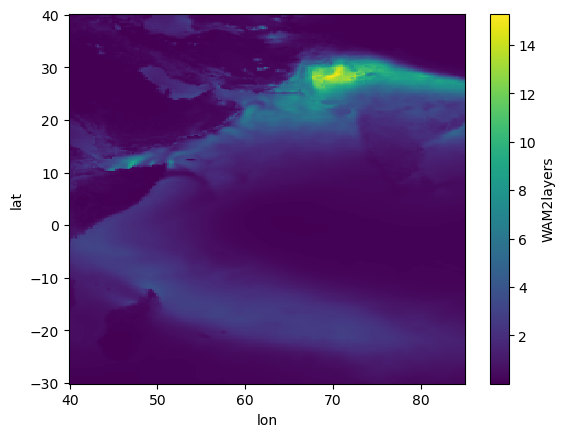

In [49]:
all_maps["WAM2layers"].plot()
plt.show()

In [63]:
#Do a clustering analysis to group similar model runs together
kmeans = KMeans(n_clusters=3, random_state=12).fit(
    all_maps.to_array().transpose("variable", "lat", "lon").values.reshape(
        13, -1
    )
)

labels = kmeans.labels_
for i, model in enumerate(all_maps.data_vars):
    print(f"{model}: Cluster {labels[i]}")  

WAM2layers: Cluster 0
2LDRM: Cluster 0
UTrack Ens2: Cluster 0
BTrIMS: Cluster 0
TRACMASS: Cluster 1
FLEXPART-SSW08 (HAMSTER) Ens5: Cluster 0
FLEXPART-SSW08 (WaterSip): Cluster 1
FLEXPART-SSW08 (UniVie): Cluster 1
LAGRANTO-SSW08: Cluster 1
FLEXPART-SSW08 (IBCAS): Cluster 1
FLEXPART-SSW08 (HKUST) Ens2: Cluster 1
FLEXPART-SSW08 (LATTIN): Cluster 1
FLEXPART-SJ04 (LATTIN): Cluster 2


c:\Users\chris\OneDrive\Documenten\Data\Moisture_tracking_intercomparison\.conda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


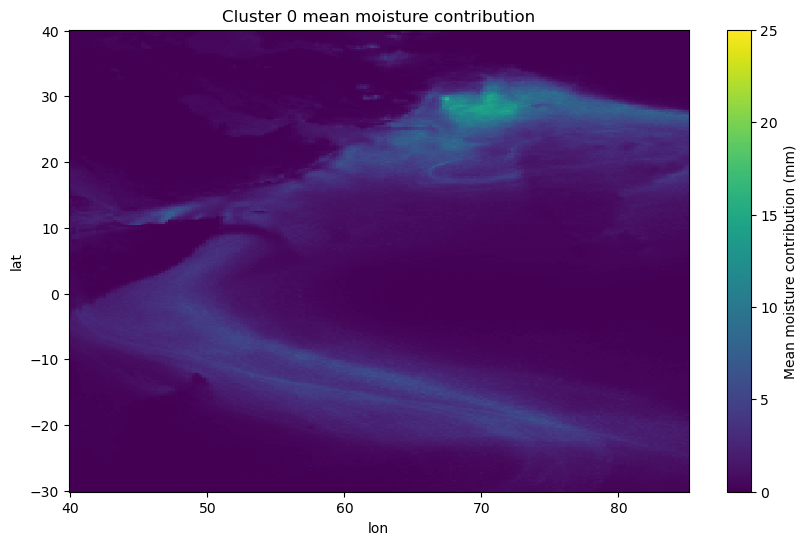

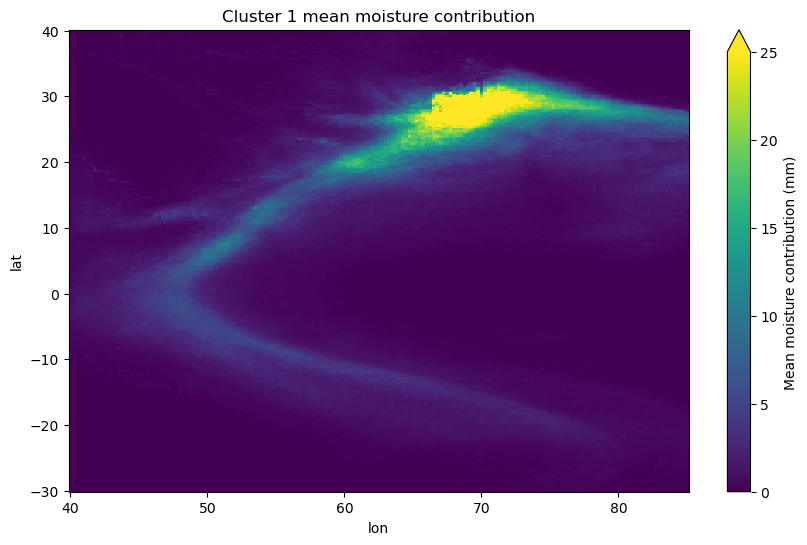

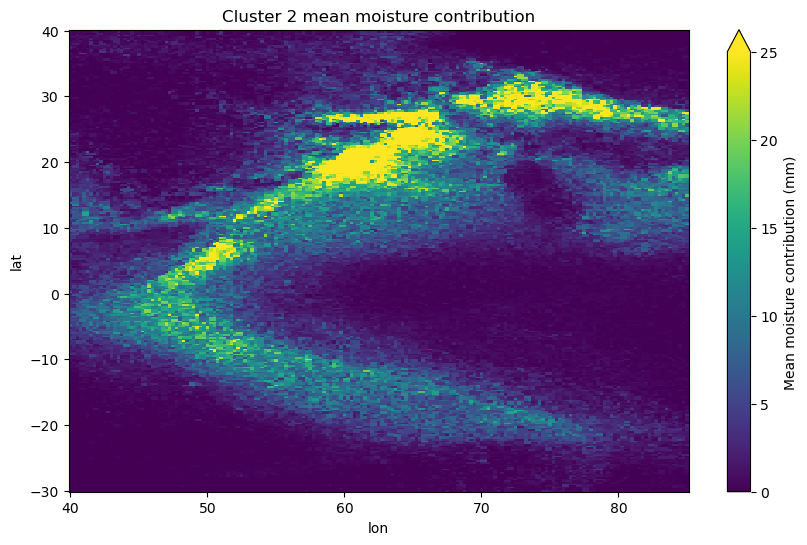

In [75]:
#Plot mean of different defined clusters
for cluster in np.unique(labels):
    plt.figure(figsize=(10, 6))
    cluster_members = [
        model
        for i, model in enumerate(all_maps.data_vars)
        if labels[i] == cluster
    ]
    cluster_mean = all_maps[cluster_members].to_array(dim='new').mean('new')
    cluster_mean.plot(
        cmap="viridis",
        vmin=0,
        vmax=25,
        cbar_kwargs={"label": "Mean moisture contribution (mm)"},
    )   

    plt.title(f"Cluster {cluster} mean moisture contribution")
    plt.show()



<xarray.DataArray (lat: 281, lon: 181)> Size: 407kB
dask.array<mean_agg-aggregate, shape=(281, 181), dtype=float64, chunksize=(281, 181), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 2kB -30.0 -29.75 -29.5 -29.25 ... 39.5 39.75 40.0
  * lon      (lon) float64 1kB 40.0 40.25 40.5 40.75 ... 84.25 84.5 84.75 85.0